<a href="https://colab.research.google.com/github/Devil-92/100_Days_of_ML/blob/main/EvaluationMetrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

If We talk about classification problems , common metrics are :<br>


*   Accuracy
* Precison (P)
* Recall (R)
* F1 Score (F1)
* Area Under Roc Curve (AUC)
* Log loss
* Precision at k (P@k)
* Average Precision at k (AP@k)
* Mean Average Precision at k (MAP@K)



When it comes to regression, the most commonly used evaluation metrics are:
- Mean absolute error (MAE)
- Mean squared error (MSE)
- Root mean squared error (RMSE)
- Root mean squared logarithmic error (RMSLE)
- Mean percentage error (MPE)
- Mean absolute percentage error (MAPE)
- R2

In [1]:
print('When we have a equal number of positive and negative samples in a binary classification metric we generally use accuracy , recall , precision and F1')

When we have a equal number of positive and negative samples in a binary classification metric we generally use accuracy , recall , precision and F1


## For Binary Class

### Accuracy

In [2]:
print('Pythonic Implementation of accuracy')

Pythonic Implementation of accuracy


In [3]:
def accuracy(y_true , y_pred) :
  cnt = 0
  for yt , yp in zip(y_true , y_pred) :
    if yt == yp :
      cnt += 1

  return cnt/len(y_true)

In [4]:
print('Using Scikit Learn library')

Using Scikit Learn library


In [5]:
from sklearn import metrics

l1 = [1 , 1 , 1 , 1 , 0 ]
l2 = [1 , 1 , 0 , 0 , 0 ]

metrics.accuracy_score(l1 , l2)

0.6

In [6]:
print('Now lets implement TP , TN , FP , FN in python')

Now lets implement TP , TN , FP , FN in python


### Recall and Precision

In [7]:
def true_pos(y_true , y_pred) :
  cnt = 0
  for i , j in zip(y_true , y_pred) :
    if i == 1 and j == 1 :
      cnt += 1
  return cnt

In [8]:
def true_neg(y_true , y_pred) :
  cnt = 0
  for i , j in zip(y_true , y_pred) :
    if i == 0 and j == 0 :
      cnt += 1
  return cnt

In [9]:
def false_pos(y_true , y_pred) :
  cnt = 0
  for i , j in zip(y_true , y_pred) :
    if i == 0 and j == 1 :
      cnt += 1
  return cnt

In [10]:
def false_neg(y_true , y_pred) :
  cnt = 0
  for i , j in zip(y_true , y_pred) :
    if i == 1 and j == 0 :
      cnt += 1
  return cnt

In [11]:
l1 = [0 , 1 , 1 , 1 , 0 , 0 , 0 , 1]
l2 = [0 , 1 , 0 , 1 , 0 , 1 , 0 , 0]

In [12]:
true_neg(l1 , l2)

3

In [13]:
true_pos(l1 , l2)

2

In [14]:
false_pos(l1 , l2)

1

In [15]:
false_neg(l1 , l2)

2

In [16]:
print('We will redefine Accuracy')

We will redefine Accuracy


In [17]:
print("Accuracy = (TP + TN) / (TN + TP + FP + FN)")

Accuracy = (TP + TN) / (TN + TP + FP + FN)


In [18]:
def acc_v2(y_t , y_p) :
  tp = true_pos(y_t , y_p)
  tn = true_neg(y_t , y_p)
  fp = false_neg(y_t , y_p)
  fn = false_pos(y_t , y_p)

  return (tp + tn)/(tp + tn + fp + fn)

In [19]:
accuracy(l1 , l2)

0.625

In [20]:
acc_v2(l1 , l2)

0.625

In [21]:
metrics.accuracy_score(l1 , l2)

0.625

In [22]:
print('Verified all Our Systems give same result')

Verified all Our Systems give same result


#### Precision

In [23]:
print('Now we will define new metric which is precision')

Now we will define new metric which is precision


In [24]:
print('Precision = TP/(TP + FP)')

Precision = TP/(TP + FP)


In [25]:
print('Out of all the instance whom we called positive how many are actually correct')

Out of all the instance whom we called positive how many are actually correct


In [26]:
def precision(y_true , y_pred) :
  tp = true_pos(y_true , y_pred)
  fp = false_pos(y_true , y_pred)
  return tp / (tp + fp)

In [27]:
precision(l1 , l2)

0.6666666666666666

In [28]:
metrics.precision_score(l1 , l2)

0.6666666666666666

#### Recall

In [29]:
print('We Will move to recall')

We Will move to recall


In [30]:
print('Recall = TP / TP + FN')

Recall = TP / TP + FN


In [31]:
print('Out of all the instance which are positive how many are we able to guess')

Out of all the instance which are positive how many are we able to guess


In [32]:
def recall(y_true , y_pred) :
  tp = true_pos(y_true , y_pred)
  fn = false_neg(y_true , y_pred)
  return tp / (tp + fn)

In [33]:
recall(l1 , l2)

0.5

In [34]:
metrics.recall_score(l1 , l2)

0.5

In [35]:
print('For a good model precision and recall both should be high')

For a good model precision and recall both should be high


### F1

In [36]:
print('F1 is a metric which combines both recall and precision , it is a harmonic mean of recall and precison')

F1 is a metric which combines both recall and precision , it is a harmonic mean of recall and precison


In [37]:
print('F1 = (2 * Recall * Precision) / (Recall + Precision)')

F1 = (2 * Recall * Precision) / (Recall + Precision)


In [38]:
def f1(y_true , y_pred) :
  p = precision(y_true , y_pred)
  r = recall(y_true , y_pred)
  return 2 * p * r / (p + r)

In [39]:
f1(l1 , l2)

0.5714285714285715

In [40]:
metrics.f1_score(l1 , l2)

0.5714285714285714

In [41]:
print('While dealing with dataset if we have skewed target we should look for F1 instead of accuracy')

While dealing with dataset if we have skewed target we should look for F1 instead of accuracy


### ROC AUC

In [42]:
print('True Positive Rate(TPR) is recall which is also called sensitivity')

True Positive Rate(TPR) is recall which is also called sensitivity


In [43]:
print('TPR = TP / (TP + FN)')

TPR = TP / (TP + FN)


In [44]:
def tpr(y_true , y_pred) :
  return recall(y_true , y_pred)

In [45]:
print('False Positive Rate or FPR is defined by FPR = FP/(TN + FP)')

False Positive Rate or FPR is defined by FPR = FP/(TN + FP)


In [46]:
def fpr(y_true , y_pred) :
  fp = false_pos(y_true , y_pred)
  tn = true_neg(y_true , y_pred)
  return fp/(tn + fp)

In [47]:
print('1 - FPR is also known as specificity or True Negative Rate (TNR)')

1 - FPR is also known as specificity or True Negative Rate (TNR)


In [48]:
tpr_rate = []
fpr_rate = []

y_true = [0 , 0 , 0 , 0 , 1 , 0 , 1 , 0 , 0 , 1 , 0 , 1 , 0 , 0 , 1]

y_pred = [0.1, 0.3, 0.2, 0.6, 0.8, 0.05,
           0.9, 0.5, 0.3, 0.66, 0.3, 0.2,
           0.85, 0.15, 0.99]

threshold = [0, 0.1, 0.2, 0.3, 0.4, 0.5,
             0.6, 0.7, 0.8, 0.85, 0.9, 0.99, 1.0]

for thres in threshold :
  temp_pred = [1 if x >= thres else 0 for x in y_pred]

  temp_tpr = tpr(y_true , temp_pred)
  temp_fpr = fpr(y_true , temp_pred)

  tpr_rate.append(temp_tpr)
  fpr_rate.append(temp_fpr)

In [49]:
import pandas as pd
import numpy as np

In [50]:
df = pd.DataFrame([threshold , tpr_rate , fpr_rate] , index = ['Threshold' , 'TPR_Rate' , 'FPR_Rate'])

In [51]:
df.T.head()

,Threshold,TPR_Rate,FPR_Rate
0,0.0,1.0,1.0
1,0.1,1.0,0.9
2,0.2,1.0,0.7
3,0.3,0.8,0.6
4,0.4,0.8,0.3


In [52]:
import matplotlib.pyplot as plt

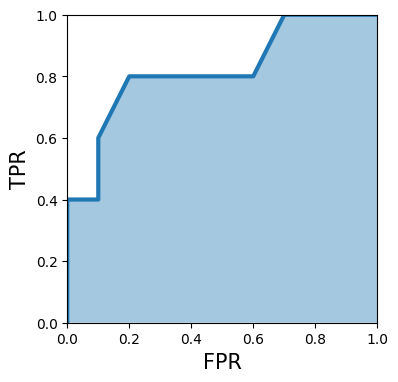

In [53]:
plt.figure(figsize = (4 , 4))
plt.fill_between(fpr_rate , tpr_rate , alpha = 0.4)
plt.plot(fpr_rate , tpr_rate , lw = 3)
plt.xlim(0 , 1)
plt.ylim(0 , 1)
plt.xlabel('FPR' , fontsize = 15)
plt.ylabel('TPR' , fontsize = 15)
plt.show()

In [54]:
print('This curve is also known as Receiver Operating Characteristic')

This curve is also known as Receiver Operating Characteristic


In [55]:
print('Area under it is another metric known as AUC')

Area under it is another metric known as AUC


In [56]:
print('Scikit learn had roc_auc_score for it')

Scikit learn had roc_auc_score for it


In [57]:
metrics.roc_auc_score(y_true , y_pred)

np.float64(0.8300000000000001)

In [58]:
print('AUC = 0.5 means prediction are random and for binary if I predict 0.5 for all targets')

AUC = 0.5 means prediction are random and for binary if I predict 0.5 for all targets


In [59]:
print('AUC value between 0.5 and 1 means our predictions are worse than random')

AUC value between 0.5 and 1 means our predictions are worse than random


In [60]:
print('If you pick one random positive sample and one random negative sample, AUC is the probability that the model gives the positive one a higher score')

If you pick one random positive sample and one random negative sample, AUC is the probability that the model gives the positive one a higher score


In [61]:
print('Not affected by the choice of decision threshold or by calibration of probabilities')

Not affected by the choice of decision threshold or by calibration of probabilities


In [62]:
print('In binary we have the class probabilities and by using threshold we can get binary variable predictions')

In binary we have the class probabilities and by using threshold we can get binary variable predictions


In [63]:
print('Prediction Class = (Probability >= Threshold)')

Prediction Class = (Probability >= Threshold)


In [64]:
print("If we do not want to have too many false positives we should have higher threshold value")

If we do not want to have too many false positives we should have higher threshold value


In [65]:
print('But this will increase false negatives and hence a trade off is there and the best threshold is selected')

But this will increase false negatives and hence a trade off is there and the best threshold is selected


In [66]:
print('Most of the time the top left value of ROC Curve gives a good threshold')

Most of the time the top left value of ROC Curve gives a good threshold


### Log Loss

In [67]:
print('Log Loss = -1 * [(target * log(prediction) + (1-target) * log(1 - (prediction))]')

Log Loss = -1 * [(target * log(prediction) + (1-target) * log(1 - (prediction))]


In [68]:
print("The log loss punishes quite high for an incorrect prediction in layman terms don't be sure and wrong")

The log loss punishes quite high for an incorrect prediction in layman terms don't be sure and wrong


In [69]:
print('Log Loss is also called binary cross entropy')

Log Loss is also called binary cross entropy


In [70]:
def log_loss(y_true , y_pred) :
  epsilon = 1e-15

  loss = []

  for yt , yp in zip(y_true , y_pred) :

    yp = np.clip(yp , epsilon , 1 - epsilon)

    single_loss = -1 * ((yt) * np.log(yp) + (1 - yt) * np.log(1-yp))

    loss.append(single_loss)

  return np.mean(loss)

In [71]:
log_loss(y_true , y_pred)

np.float64(0.49882711861432294)

In [72]:
metrics.log_loss(y_true , y_pred)

0.49882711861432294

## For MultiClass

### Macro Averaged Precision

In [73]:
print('Calculate precision for all classes individually and then average them')

Calculate precision for all classes individually and then average them


In [74]:
def macro_precision(y_true , y_pred) :

  num_classes = len(np.unique(y_true))

  precision = 0

  for i in range(num_classes) :

    temp_y_true = [1 if p == i else 0 for p in y_true]
    temp_y_pred = [1 if p == i else 0 for p in y_pred]

    tp = true_pos(temp_y_true , temp_y_pred)
    fp = false_pos(temp_y_true , temp_y_pred)

    temp_precision = tp / (tp + fp)

    precision += temp_precision

  return precision/num_classes

### Micro Averaged Precision

In [75]:
print('Calculate class wise true positive and false positive and use that to calculate overall Precision')

Calculate class wise true positive and false positive and use that to calculate overall Precision


In [76]:
def micro_precision(y_true , y_pred) :
  num_classes = len(np.unique(y_true))

  precision = 0
  tp = 0
  fp = 0

  for i in range(num_classes) :
    temp_y_t = [1 if i == p else 0 for p in y_true]
    temp_y_p = [1 if i == p else 0 for p in y_pred]

    tp += true_pos(temp_y_t , temp_y_p)
    fp += false_pos(temp_y_t , temp_y_p)

  return (tp)/(fp + tp)

### Weighted Precision

In [77]:
print("Same as macro but in this case , it is weighted average depending on the number of items in each class")

Same as macro but in this case , it is weighted average depending on the number of items in each class


In [78]:
from collections import Counter

def weighted_precision(y_true , y_pred) :

  num_classes = len(np.unique(y_true))

  precision = 0

  count = Counter(y_true)

  for i in range(num_classes) :
    temp_y_t = [1 if p == i else 0 for p in y_true]
    temp_y_p = [1 if p == i else 0 for p in y_pred]

    tp = true_pos(temp_y_t , temp_y_p)
    fp = false_pos(temp_y_t , temp_y_p)

    precision += count[i] * (tp / (tp + fp))

  return (precision / len(y_true))

In [79]:
l1 = [0 , 1 , 2 , 0 , 1 , 2 , 0 , 2 , 2]
l2= [0 , 2 , 1 , 0 , 2 , 1 , 0 , 0 , 2]

In [80]:
macro_precision(l1 , l2)

0.3611111111111111

In [81]:
metrics.precision_score(l1 , l2 , average = 'macro')

0.3611111111111111

In [82]:
micro_precision(l1 , l2)

0.4444444444444444

In [83]:
metrics.precision_score(l1 , l2 , average = 'micro')

0.4444444444444444

In [84]:
weighted_precision(l1 , l2)

0.39814814814814814

In [85]:
metrics.precision_score(l1 , l2 , average = 'weighted')

0.39814814814814814

### Weighted F1

In [86]:
print('F1 For multiclass :')

F1 For multiclass :


In [87]:
def weighted_f1(y_true , y_pred) :

  num_classes = len(np.unique(y_true))

  count = Counter(y_true)

  weighted_f1 = 0

  for i in range(num_classes) :

    temp_y_t = [1 if i == p else 0 for p in y_true]
    temp_y_p = [1 if i == p else 0 for p in y_pred]

    tp = true_pos(temp_y_t , temp_y_p)
    fn = false_neg(temp_y_t , temp_y_p)
    fp = false_pos(temp_y_t , temp_y_p)

    recall = tp/(fn+tp)

    precision = tp/(fp + tp)

    if recall + precision == 0 :
      temp_f1 = 0
    else :
      temp_f1 = 2 * recall * precision / (recall + precision)

    weighted_f1 += temp_f1 * count[i]

  return weighted_f1 / len(y_true)

In [88]:
weighted_f1(l1 , l2)

0.41269841269841273

In [89]:
metrics.f1_score(l1 , l2 , average = 'weighted')

0.4126984126984127

### One vs Rest Log Loss

In [90]:
def log_loss_ovr(y_true , y_pred) :
  num_classes = np.unique(y_true)
  per_class = [log_loss((y_true == c).astype(int) , y_pred[ : , i]) for i , c in enumerate(num_classes)]
  print(per_class)
  return np.mean(per_class)

In [91]:
y_true = np.array([0, 1, 2, 1, 0])
y_pred = np.array([
    [0.7, 0.2, 0.1],
    [0.1, 0.8, 0.1],
    [0.2, 0.3, 0.5],
    [0.1, 0.7, 0.2],
    [0.6, 0.3, 0.1],
])

In [92]:
metrics.log_loss(y_true , y_pred)

0.4280932487035221

In [93]:
log_loss_ovr(y_true , y_pred)

[np.float64(0.2602730300669171), np.float64(0.3032623868889234), np.float64(0.24647445576952678)]


np.float64(0.2700032909084557)

In [94]:
log_loss(y_true , y_pred)

np.float64(1.183197657884329)

### One Vs Rest AUC

In [95]:
metrics.roc_auc_score(y_true, y_pred, multi_class='ovr', average='weighted')

np.float64(1.0)

In [96]:
metrics.roc_auc_score(y_true, y_pred, multi_class='ovr', average=None)

array([1., 1., 1.])

In [97]:
print('If I rank all samples by their predicted probability for class c, do the actual class-c samples end up ranked higher than the non-class-c samples')

If I rank all samples by their predicted probability for class c, do the actual class-c samples end up ranked higher than the non-class-c samples


In [98]:
print('In our particular example it is rated above for every time')

In our particular example it is rated above for every time


In [99]:
l1 = [0 , 1 , 2 , 0 , 1 , 2 , 0 , 2 , 2]
l2 = [0 , 2 , 1 , 0 , 2 , 1 , 0 , 0 , 2]

In [100]:
metrics.confusion_matrix(l1 , l2)

array([[3, 0, 0],
       [0, 0, 2],
       [1, 2, 1]])

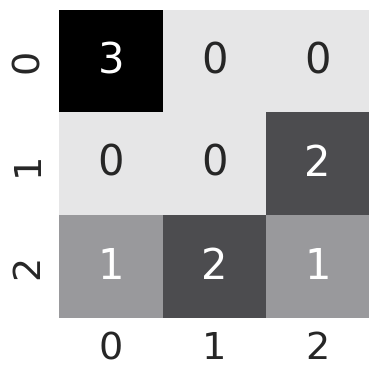

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = metrics.confusion_matrix(l1 , l2)

plt.figure(figsize = (4 , 4))
cmap = sns.cubehelix_palette(50 , hue = 0.05 , rot = 0 , light = 0.9 , dark = 0 , as_cmap = True)

sns.set(font_scale = 2.5)

sns.heatmap(cm , annot = True , cmap = cmap , cbar = False)
plt.show()

## For Multi Label

In [102]:
print('When One Instance has multiple targets associated with it')

When One Instance has multiple targets associated with it


### P@K

In [103]:
print('Stands for precision at k')

Stands for precision at k


In [104]:
def pk(y_true , y_pred , k) :

  if k == 0 :
    return 0

  y_pred = y_pred[:k]

  set_y_t = set(y_true)
  set_y_p = set(y_pred)

  relevent = set_y_p.intersection(set_y_t)

  return (len(relevent) / k)

In [105]:
y_true = [
    [1 , 2 , 3] ,
    [0 , 2 ] ,
    [1] ,
    [2 , 3] ,
    [1 , 0] ,
    []
]

y_pred = [
    [0 , 1 , 2] ,
    [1] ,
    [0 , 2 , 3] ,
    [2 , 3 , 4 , 0] ,
    [0 , 1 , 2] ,
    [0]
]

In [106]:
for i in range(len(y_true)) :
  print(f"For y_true = {y_true[i]}")
  print(f"For y_pred = {y_pred[i]}")
  print()
  for j in range(1 , 5) :
    print(f"For k = {j}")
    print(pk(y_true[i] , y_pred[i] , j))
  print()

For y_true = [1, 2, 3]
For y_pred = [0, 1, 2]

For k = 1
0.0
For k = 2
0.5
For k = 3
0.6666666666666666
For k = 4
0.5

For y_true = [0, 2]
For y_pred = [1]

For k = 1
0.0
For k = 2
0.0
For k = 3
0.0
For k = 4
0.0

For y_true = [1]
For y_pred = [0, 2, 3]

For k = 1
0.0
For k = 2
0.0
For k = 3
0.0
For k = 4
0.0

For y_true = [2, 3]
For y_pred = [2, 3, 4, 0]

For k = 1
1.0
For k = 2
1.0
For k = 3
0.6666666666666666
For k = 4
0.5

For y_true = [1, 0]
For y_pred = [0, 1, 2]

For k = 1
1.0
For k = 2
1.0
For k = 3
0.6666666666666666
For k = 4
0.5

For y_true = []
For y_pred = [0]

For k = 1
0.0
For k = 2
0.0
For k = 3
0.0
For k = 4
0.0



### AP@K

In [107]:
print('Average precision at K')

Average precision at K


In [108]:
def apk(y_true , y_pred , k) :

  y_pred = y_pred[:k]

  score = 0
  num_hits = 0

  for i , j in enumerate(y_pred) :
    if j in y_true :
      num_hits += 1
      score += num_hits / (i + 1)

  if len(y_true) == 0 :
    return 0
  return score/ min(k , len(y_true))

In [109]:
for i in range(len(y_true)) :
  print(f"For y_true = {y_true[i]}")
  print(f"For y_pred = {y_pred[i]}")
  print(f"Value of AP@K = {apk(y_true[i] , y_pred[i] , len(y_pred[i]))}")
  print()

For y_true = [1, 2, 3]
For y_pred = [0, 1, 2]
Value of AP@K = 0.38888888888888884

For y_true = [0, 2]
For y_pred = [1]
Value of AP@K = 0.0

For y_true = [1]
For y_pred = [0, 2, 3]
Value of AP@K = 0.0

For y_true = [2, 3]
For y_pred = [2, 3, 4, 0]
Value of AP@K = 1.0

For y_true = [1, 0]
For y_pred = [0, 1, 2]
Value of AP@K = 1.0

For y_true = []
For y_pred = [0]
Value of AP@K = 0



### MAP@K

In [110]:
print('Mean Average Precision at K')

Mean Average Precision at K


In [111]:
def mapk(y_true , y_pred , k) :
  return np.mean([apk(y_true_single , y_pred_single , k ) for y_true_single , y_pred_single in zip(y_true , y_pred)])

In [112]:
mapk(y_true , y_pred , 1)

np.float64(0.3333333333333333)

In [113]:
mapk(y_true , y_pred , 3)

np.float64(0.39814814814814814)

### Log Loss for Multilabel

In [114]:
def log_loss_for_multi(y_true , y_pred) :

  per_label = [
      log_loss(y_true[: , c] , y_pred[: , c]) for c in range(y_true.shape[1])
  ]
  for i in range(y_true.shape[1]) :
    print(f"Loss of label {i} : {per_label[i]}")
  print()
  return np.mean(per_label)

In [115]:
y_true = np.array([
    [1, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
])

y_pred = np.array([
    [0.9, 0.8, 0.2],
    [0.1, 0.7, 0.6],
    [0.6, 0.3, 0.1],
])

In [116]:
log_loss_for_multi(y_true , y_pred)

Loss of label 0 : 0.24051555169388109
Loss of label 1 : 0.3121644797305582
Loss of label 2 : 0.2797765635793423



np.float64(0.2774855316679272)

## Regression

### Mean Absolute Error ( MAE )

In [118]:
def mean_abs(y_true , y_pred) :
  abs_error = 0
  for i , j in zip(y_true , y_pred) :
    abs_error += abs(i - j)
  return (abs_error/len(y_true))

In [119]:
l1 = [1 , 3 , 3 , 5 , 6]
l2 = [9 , 2 , 2 , 1 , 6]

In [120]:
mean_abs(l1 , l2)

2.8

In [121]:
metrics.mean_absolute_error(l1 , l2)

2.8

In [117]:
print('Error = True Value - Predicted Value')

Error = True Value - Predicted Value


### Mean Squared Error ( MSE )

In [122]:
def mean_squared(y_true , y_pred) :
  error = 0
  for i , j in zip(y_true , y_pred) :
    error += np.square(i - j)

  return error/len(y_true)

In [123]:
mean_squared(l1 , l2)

np.float64(16.4)

In [124]:
metrics.mean_squared_error(l1 , l2)

16.4

### Root Mean Squared Error (RMSE)

In [125]:
def root_mean_squared(y_true , y_pred) :
  return np.sqrt(mean_squared(y_true , y_pred))

In [126]:
root_mean_squared(l1 , l2) == metrics.root_mean_squared_error(l1 , l2)

np.True_

### Mean Squared Logrithmic Error (MSLE)

In [127]:
def mean_squared_log(y_true , y_pred) :
  error = 0
  for i , j in zip(y_true , y_pred) :
    error += (np.log(1 + i) - np.log(1 + j)) ** 2
  return error/len(y_true)

In [128]:
mean_squared_log(l1 , l2)

np.float64(0.7925522608826241)

In [129]:
metrics.mean_squared_log_error(l1 , l2)

0.7925522608826241

### Mean Absolute Percentage Error (MAPE)

In [130]:
def mean_abs_percent(y_true , y_pred) :
  error = 0
  for i , j in zip(y_true , y_pred) :
    error += np.abs(i - j) / i

  return error / len(y_true)

In [131]:
mean_abs_percent(l1 , l2)

np.float64(1.8933333333333338)

In [132]:
metrics.mean_absolute_percentage_error(l1 , l2)

1.8933333333333338

### Coefficient of Determination (R2)

In [133]:
def r2(y_true , y_pred) :
  num = 0
  dem = 0
  y_true_mean = np.mean(y_true)

  for i , j in zip(y_true , y_pred) :
    num += (i - j) ** 2

    dem += (i - y_true_mean) ** 2

  return 1 - (num)/dem

In [134]:
r2(l1 , l2)

np.float64(-4.394736842105263)

In [135]:
metrics.r2_score(l1 , l2)

-4.394736842105263

### Quadratic Weighted Kappa or Cohan's Kappa (QWK)

In [136]:
l1 = [1 , 2 , 3 , 1 , 2 , 3 , 1 , 2 , 3]
l2 = [2 , 1 , 3 , 1 , 2 , 3 , 3 , 1 , 2]

In [137]:
metrics.cohen_kappa_score(l1 , l2)

np.float64(0.16666666666666663)

In [138]:
metrics.cohen_kappa_score(l1 , l2 , weights = 'quadratic')

np.float64(0.33333333333333337)

In [139]:
metrics.cohen_kappa_score(l1 , l2 , weights = 'linear')

np.float64(0.25)

In [140]:
metrics.accuracy_score(l1 , l2)

0.4444444444444444

QWK measures the “agreement”
between two “ratings”. The ratings can be any real numbers in 0 to N. And
predictions are also in the same range. An agreement can be defined as how close
these ratings are to each other. So, it’s suitable for a classification problem with N
different categories/classes. If the agreement is high, the score is closer towards 1.0.
In the case of low agreement, the score is close to 0.

Used in:<br>
Evaluating classifiers on imbalanced data<br>
Ordinal prediction tasks (QWK)<br>
Comparing predictions across model versions


### Mathew's Correlation Coefficient (MCC)


MCC = (TP × TN − FP × FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN)) <br>
MCC ranges
from -1 to 1. 1 is perfect prediction, -1 is imperfect prediction, and 0 is random
prediction


In [141]:
def mcc(y_true , y_pred) :
  tp = true_pos(y_true , y_pred)
  tn = true_neg(y_true , y_pred)
  fp = false_pos(y_true , y_pred)
  fn = false_neg(y_true , y_pred)

  num = (tp * tn - fp * fn)
  den = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) ** 0.5

  if den == 0 :
    return 0

  return (num/den)

In [142]:
l1 = [0 , 1 , 0 , 1 , 0 , 1]
l2 = [1 , 1 , 1 , 0 , 1 , 1]

In [143]:
mcc(l1 , l2)

-0.4472135954999579

In [144]:
metrics.matthews_corrcoef(l1 , l2)

np.float64(-0.4472135954999579)

## For Unsupervised Learning

"One thing to keep in mind is that to evaluate un-supervised methods, for example,
some kind of clustering, it’s better to create or manually label the test set and keep
it separate from everything that is going on in your modelling part. When you are
done with clustering, you can evaluate the performance on the test set simply by
using any of the supervised learning metrics."